In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
!pip install -q gdown

In [5]:
import gdown

file_id = "1VSmOS5IR6OlVTP_Fxhm5mFdZGiQn4ES2"

url = f"https://drive.google.com/uc?id={file_id}"

output_file = "bank_marketing_dataset"

gdown.download(
    url,
    output_file,
    quiet=False,
    fuzzy=True
)

print("Dataset downloaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1VSmOS5IR6OlVTP_Fxhm5mFdZGiQn4ES2
To: /content/bank_marketing_dataset
100%|██████████| 4.93M/4.93M [00:00<00:00, 37.6MB/s]

Dataset downloaded successfully.


In [6]:
import os

print("Downloaded file:")
print(os.path.abspath(output_file))

print("\nFile size:")
print(os.path.getsize(output_file), "bytes")

Downloaded file:
/content/bank_marketing_dataset

File size:
4928746 bytes


In [7]:
df = pd.read_csv(
    output_file,
    sep=None,
    engine="python"
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [10]:
print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])
print("Dataset Shape     :", df.shape)

Number of Rows    : 41188
Number of Columns : 21
Dataset Shape     : (41188, 21)


In [11]:
print("Column Names:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, column)

Column Names:

1 age
2 job
3 marital
4 education
5 default
6 housing
7 loan
8 contact
9 month
10 day_of_week
11 duration
12 campaign
13 pdays
14 previous
15 poutcome
16 emp.var.rate
17 cons.price.idx
18 cons.conf.idx
19 euribor3m
20 nr.employed
21 y


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [13]:
print(df.dtypes)

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [14]:
numerical_features = df.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nNumber of Numerical Features:")
print(len(numerical_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:")
print(len(categorical_features))

Numerical Features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Number of Numerical Features:
10

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Number of Categorical Features:
11


In [15]:
target_column = "y"

numerical_predictors = [
    col for col in numerical_features
    if col != target_column
]

categorical_predictors = [
    col for col in categorical_features
    if col != target_column
]

print("Numerical Predictor Variables:")
print(numerical_predictors)

print("\nCategorical Predictor Variables:")
print(categorical_predictors)

print("\nTarget Variable:")
print(target_column)

Numerical Predictor Variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical Predictor Variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Target Variable:
y


In [16]:
target_column = "y"

numerical_predictors = [
    col for col in numerical_features
    if col != target_column
]

categorical_predictors = [
    col for col in categorical_features
    if col != target_column
]

print("Numerical Predictor Variables:")
print(numerical_predictors)

print("\nCategorical Predictor Variables:")
print(categorical_predictors)

print("\nTarget Variable:")
print(target_column)

Numerical Predictor Variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical Predictor Variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Target Variable:
y


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [18]:
numerical_summary = df[numerical_features].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [19]:
for column in categorical_features:

    print("\n" + "=" * 50)
    print("Column:", column)
    print("=" * 50)

    print(df[column].value_counts(dropna=False))


Column: job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Column: marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Column: education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Column: default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Column: housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

Column: loan
loan
no         33950
yes         6248
unknown      9

In [20]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
]

missing_table.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Percentage


In [21]:
print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

Total Missing Values: 0


In [22]:
unknown_counts = {}

for column in categorical_features:

    count = (
        df[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("unknown")
        .sum()
    )

    if count > 0:
        unknown_counts[column] = count

unknown_table = pd.DataFrame(
    list(unknown_counts.items()),
    columns=["Feature", "Unknown Count"]
)

if len(unknown_table) > 0:

    unknown_table["Percentage"] = (
        unknown_table["Unknown Count"] /
        len(df)
    ) * 100

    display(
        unknown_table.sort_values(
            "Unknown Count",
            ascending=False
        )
    )

else:
    print("No 'unknown' values found.")

,Feature,Unknown Count,Percentage
3,default,8597,20.872584
2,education,1731,4.202680
4,housing,990,2.403613
5,loan,990,2.403613
0,job,330,0.801204
1,marital,80,0.194231


In [23]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 12


In [24]:
duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print(
    f"Duplicate Percentage: {duplicate_percentage:.2f}%"
)

Duplicate Percentage: 0.03%


In [25]:
print(df["y"].value_counts())

y
no     36548
yes     4640
Name: count, dtype: int64


In [26]:
print(
    df["y"].value_counts(
        normalize=True
    ) * 100
)

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [27]:
target_distribution = pd.DataFrame({
    "Count": df["y"].value_counts(),
    "Percentage": (
        df["y"].value_counts(normalize=True) * 100
    )
})

target_distribution

,Count,Percentage
y,,
no,36548,88.734583
yes,4640,11.265417


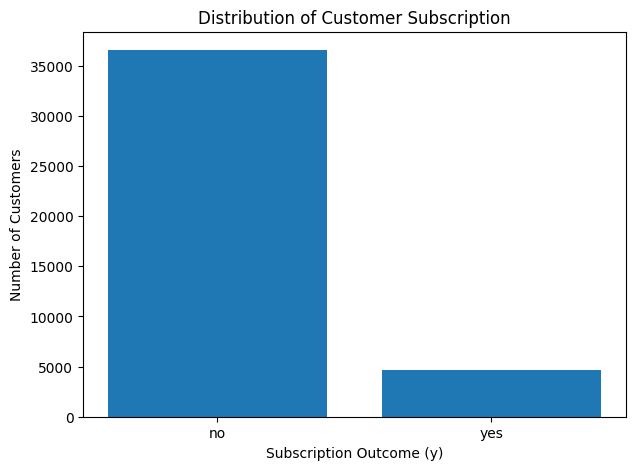

In [28]:
target_counts = df["y"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    target_counts.index.astype(str),
    target_counts.values
)

plt.title("Distribution of Customer Subscription")
plt.xlabel("Subscription Outcome (y)")
plt.ylabel("Number of Customers")

plt.show()

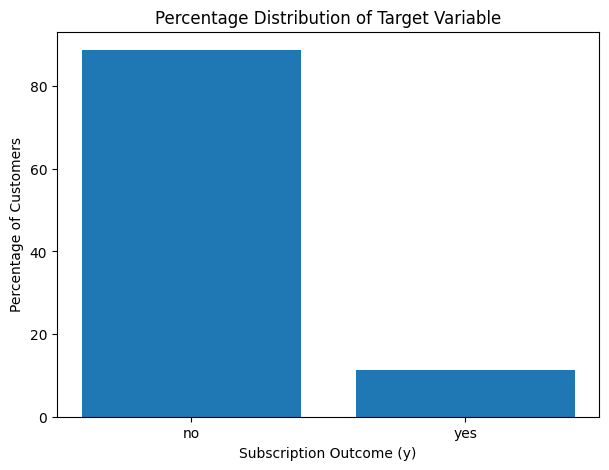

In [29]:
target_percentage = (
    df["y"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

plt.figure(figsize=(7, 5))

plt.bar(
    target_percentage.index.astype(str),
    target_percentage.values
)

plt.title("Percentage Distribution of Target Variable")
plt.xlabel("Subscription Outcome (y)")
plt.ylabel("Percentage of Customers")

plt.show()

In [30]:
print("Unique values in target variable:")
print(df["y"].unique())

Unique values in target variable:
['no' 'yes']


In [31]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Number of Unique Values": [
        df[col].nunique()
        for col in df.columns
    ]
})

unique_values

,Column,Number of Unique Values
0,age,78
1,job,12
2,marital,4
3,education,8
4,default,3
5,housing,3
6,loan,3
7,contact,2
8,month,10
9,day_of_week,5


In [32]:
print("=" * 60)
print("BANK MARKETING DATASET - EXPLORATORY SUMMARY")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Rows:")
print(df.shape[0])

print("\nNumber of Columns:")
print(df.shape[1])

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Variable Distribution:")
print(df["y"].value_counts())

print("\nTarget Variable Percentage:")
print(
    df["y"].value_counts(normalize=True) * 100
)

print("\nUnique Target Values:")
print(df["y"].unique())

BANK MARKETING DATASET - EXPLORATORY SUMMARY

Dataset Shape:
(41188, 21)

Number of Rows:
41188

Number of Columns:
21

Numerical Features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Missing Values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Duplicate Rows:
12

Target Variable Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Target Variable Percentage:
y
no   

In [33]:
df.shape

(41188, 21)

In [34]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [36]:
df["y"].value_counts()

,count
y,
no,36548
yes,4640


In [37]:
df["y"].value_counts(normalize=True) * 100

,proportion
y,
no,88.734583
yes,11.265417


In [40]:
# Create a copy of the original dataset
data = df.copy()

print("Dataset copied successfully.")
print(data.shape)

Dataset copied successfully.
(41188, 21)


In [41]:
print("Missing values in each column:\n")
print(data.isnull().sum())

print("\nTotal Missing Values:")
print(data.isnull().sum().sum())

Missing values in each column:

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Total Missing Values:
0


In [42]:
categorical_columns = data.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nUnknown values in categorical columns:\n")

for column in categorical_columns:
    unknown_count = (
        data[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("unknown")
        .sum()
    )

    if unknown_count > 0:
        print(
            f"{column}: {unknown_count} "
            f"({unknown_count / len(data) * 100:.2f}%)"
        )

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Unknown values in categorical columns:

job: 330 (0.80%)
marital: 80 (0.19%)
education: 1731 (4.20%)
default: 8597 (20.87%)
housing: 990 (2.40%)
loan: 990 (2.40%)


In [43]:
for column in categorical_columns:
    data[column] = (
        data[column]
        .astype(str)
        .str.strip()
        .replace({
            "unknown": "Unknown",
            "UNKNOWN": "Unknown"
        })
    )

print("Unknown values handled as a separate category.")

Unknown values handled as a separate category.


In [44]:
numerical_columns = data.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = data.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Fill numerical missing values with median
for column in numerical_columns:
    data[column] = data[column].fillna(
        data[column].median()
    )

# Fill categorical missing values with mode
for column in categorical_columns:
    data[column] = data[column].fillna(
        data[column].mode()[0]
    )

print("Missing values handled successfully.")

print(
    "Remaining Missing Values:",
    data.isnull().sum().sum()
)

Missing values handled successfully.
Remaining Missing Values: 0


In [45]:
print("Target values before encoding:")
print(data["y"].value_counts())

Target values before encoding:
y
no     36548
yes     4640
Name: count, dtype: int64


In [46]:
data["y"] = (
    data["y"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0
    })
)

print("\nTarget values after encoding:")
print(data["y"].value_counts())


Target values after encoding:
y
0    36548
1     4640
Name: count, dtype: int64


In [47]:
print(
    "Missing values in y:",
    data["y"].isnull().sum()
)

Missing values in y: 0


In [48]:
X = data.drop("y", axis=1)

y = data["y"]

print("Feature Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Dataset Shape: (41188, 20)
Target Shape: (41188,)


In [49]:
X.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,Unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


In [50]:
y.head()

,y
0,0
1,0
2,0
3,0
4,0


In [51]:
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Numerical Features:",
      len(numerical_features))

print("Number of Categorical Features:",
      len(categorical_features))

Numerical Features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Number of Numerical Features: 10
Number of Categorical Features: 10


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape :", X_test.shape)

print("Training Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

Training Feature Shape: (32950, 20)
Testing Feature Shape : (8238, 20)
Training Target Shape : (32950,)
Testing Target Shape  : (8238,)


In [53]:
print("Overall Target Distribution:")
print(y.value_counts(normalize=True))

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True))

Overall Target Distribution:
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

Training Target Distribution:
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

Testing Target Distribution:
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


In [58]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)
numerical_transformer = StandardScaler()
preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )

    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [59]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Preprocessing completed successfully.")

Preprocessing completed successfully.


In [64]:
# 1. Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"),
         categorical_features)
    ]
)

# 2. Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# 3. Transform testing data
X_test_processed = preprocessor.transform(X_test)

# 4. Check result
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)

X_train_processed: (32950, 53)
X_test_processed : (8238, 53)


In [67]:
print(
    "Processed Training Shape:",
    X_train_processed.shape
)

print(
    "Processed Testing Shape:",
    X_test_processed.shape
)

Processed Training Shape: (32950, 53)
Processed Testing Shape: (8238, 53)


In [68]:
encoded_categorical_features = (
    preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(
        categorical_features
    )
)

all_feature_names = (
    numerical_features +
    encoded_categorical_features.tolist()
)

print(
    "Total Features After Encoding:",
    len(all_feature_names)
)

print("\nFeature Names:")
print(all_feature_names)

Total Features After Encoding: 53

Feature Names:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'default_no', 'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']


In [69]:
print("=" * 60)
print("DATA PREPROCESSING SUMMARY")
print("=" * 60)

print(
    "\nOriginal Dataset Shape:",
    data.shape
)

print(
    "Training Dataset:",
    X_train.shape
)

print(
    "Testing Dataset:",
    X_test.shape
)

print(
    "\nNumerical Features:",
    len(numerical_features)
)

print(
    "Categorical Features:",
    len(categorical_features)
)

print(
    "\nFeatures After Encoding:",
    X_train_processed.shape[1]
)

print(
    "\nRemaining Missing Values:",
    data.isnull().sum().sum()
)

print(
    "\nTarget Classes:",
    sorted(y.unique())
)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

DATA PREPROCESSING SUMMARY

Original Dataset Shape: (41188, 21)
Training Dataset: (32950, 20)
Testing Dataset: (8238, 20)

Numerical Features: 10
Categorical Features: 10

Features After Encoding: 53

Remaining Missing Values: 0

Target Classes: [np.int64(0), np.int64(1)]

Training Class Distribution:
y
0    29238
1     3712
Name: count, dtype: int64

Testing Class Distribution:
y
0    7310
1     928
Name: count, dtype: int64


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import matplotlib.pyplot as plt

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [71]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [73]:
y_pred_logistic = logistic_model.predict(
    X_test_processed
)
logistic_accuracy = accuracy_score(
    y_test, y_pred_logistic
)

logistic_precision = precision_score(
    y_test, y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test, y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test, y_pred_logistic,
    zero_division=0
)

print("LOGISTIC REGRESSION PERFORMANCE")
print("-" * 45)

print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1-score  : {logistic_f1:.4f}")

LOGISTIC REGRESSION PERFORMANCE
---------------------------------------------
Accuracy  : 0.9162
Precision : 0.7095
Recall    : 0.4343
F1-score  : 0.5388


In [74]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "Not Subscribed",
            "Subscribed"
        ],
        zero_division=0
    )
)

Logistic Regression Classification Report:

                precision    recall  f1-score   support

Not Subscribed       0.93      0.98      0.95      7310
    Subscribed       0.71      0.43      0.54       928

      accuracy                           0.92      8238
     macro avg       0.82      0.71      0.75      8238
  weighted avg       0.91      0.92      0.91      8238



In [75]:
logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Confusion Matrix:")
print(logistic_cm)

Confusion Matrix:
[[7145  165]
 [ 525  403]]


In [76]:
k = 5

In [77]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_processed,
    y_train
)

print("kNN model trained successfully.")

kNN model trained successfully.


In [78]:
y_pred_knn = knn_model.predict(
    X_test_processed
)

In [79]:
knn_accuracy = accuracy_score(
    y_test, y_pred_knn
)

knn_precision = precision_score(
    y_test, y_pred_knn,
    zero_division=0
)

knn_recall = recall_score(
    y_test, y_pred_knn,
    zero_division=0
)

knn_f1 = f1_score(
    y_test, y_pred_knn,
    zero_division=0
)

print("K-NEAREST NEIGHBORS PERFORMANCE")
print("-" * 45)

print(f"Accuracy  : {knn_accuracy:.4f}")
print(f"Precision : {knn_precision:.4f}")
print(f"Recall    : {knn_recall:.4f}")
print(f"F1-score  : {knn_f1:.4f}")

K-NEAREST NEIGHBORS PERFORMANCE
---------------------------------------------
Accuracy  : 0.9041
Precision : 0.6068
Recall    : 0.4224
F1-score  : 0.4981


In [80]:
print("kNN Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=[
            "Not Subscribed",
            "Subscribed"
        ],
        zero_division=0
    )
)

kNN Classification Report:

                precision    recall  f1-score   support

Not Subscribed       0.93      0.97      0.95      7310
    Subscribed       0.61      0.42      0.50       928

      accuracy                           0.90      8238
     macro avg       0.77      0.69      0.72      8238
  weighted avg       0.89      0.90      0.90      8238



In [81]:
knn_cm = confusion_matrix(
    y_test,
    y_pred_knn
)

print("Confusion Matrix:")
print(knn_cm)

Confusion Matrix:
[[7056  254]
 [ 536  392]]


In [82]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svm_model.fit(
    X_train_processed,
    y_train
)

print("SVM model trained successfully.")

SVM model trained successfully.


In [84]:
y_pred_svm = svm_model.predict(
    X_test_processed
)
svm_accuracy = accuracy_score(
    y_test, y_pred_svm
)

svm_precision = precision_score(
    y_test, y_pred_svm,
    zero_division=0
)

svm_recall = recall_score(
    y_test, y_pred_svm,
    zero_division=0
)

svm_f1 = f1_score(
    y_test, y_pred_svm,
    zero_division=0
)

print("SUPPORT VECTOR MACHINE PERFORMANCE")
print("-" * 45)

print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1-score  : {svm_f1:.4f}")

SUPPORT VECTOR MACHINE PERFORMANCE
---------------------------------------------
Accuracy  : 0.9148
Precision : 0.7108
Recall    : 0.4106
F1-score  : 0.5205


In [85]:
print("SVM Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Not Subscribed",
            "Subscribed"
        ],
        zero_division=0
    )
)

SVM Classification Report:

                precision    recall  f1-score   support

Not Subscribed       0.93      0.98      0.95      7310
    Subscribed       0.71      0.41      0.52       928

      accuracy                           0.91      8238
     macro avg       0.82      0.69      0.74      8238
  weighted avg       0.90      0.91      0.90      8238



In [86]:
svm_cm = confusion_matrix(
    y_test,
    y_pred_svm
)

print("Confusion Matrix:")
print(svm_cm)

Confusion Matrix:
[[7155  155]
 [ 547  381]]


In [87]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train_processed,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [88]:
y_pred_tree = decision_tree_model.predict(
    X_test_processed
)
tree_accuracy = accuracy_score(
    y_test, y_pred_tree
)

tree_precision = precision_score(
    y_test, y_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_test, y_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_test, y_pred_tree,
    zero_division=0
)

print("DECISION TREE PERFORMANCE")
print("-" * 45)

print(f"Accuracy  : {tree_accuracy:.4f}")
print(f"Precision : {tree_precision:.4f}")
print(f"Recall    : {tree_recall:.4f}")
print(f"F1-score  : {tree_f1:.4f}")

DECISION TREE PERFORMANCE
---------------------------------------------
Accuracy  : 0.8900
Precision : 0.5115
Recall    : 0.5280
F1-score  : 0.5196


In [89]:
print("Decision Tree Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=[
            "Not Subscribed",
            "Subscribed"
        ],
        zero_division=0
    )
)

Decision Tree Classification Report:

                precision    recall  f1-score   support

Not Subscribed       0.94      0.94      0.94      7310
    Subscribed       0.51      0.53      0.52       928

      accuracy                           0.89      8238
     macro avg       0.73      0.73      0.73      8238
  weighted avg       0.89      0.89      0.89      8238



In [90]:
tree_cm = confusion_matrix(
    y_test,
    y_pred_tree
)

print("Confusion Matrix:")
print(tree_cm)

Confusion Matrix:
[[6842  468]
 [ 438  490]]


In [91]:
individual_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Support Vector Machine",
        "Decision Tree"
    ],

    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        svm_accuracy,
        tree_accuracy
    ],

    "Precision": [
        logistic_precision,
        knn_precision,
        svm_precision,
        tree_precision
    ],

    "Recall": [
        logistic_recall,
        knn_recall,
        svm_recall,
        tree_recall
    ],

    "F1-score": [
        logistic_f1,
        knn_f1,
        svm_f1,
        tree_f1
    ]
})

individual_model_results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.916242,0.709507,0.434267,0.538770
1,K-Nearest Neighbors,0.904103,0.606811,0.422414,0.498094
2,Support Vector Machine,0.914785,0.710821,0.410560,0.520492
3,Decision Tree,0.890022,0.511482,0.528017,0.519618


In [92]:
display(
    individual_model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9162,0.7095,0.4343,0.5388
1,K-Nearest Neighbors,0.9041,0.6068,0.4224,0.4981
2,Support Vector Machine,0.9148,0.7108,0.4106,0.5205
3,Decision Tree,0.8900,0.5115,0.5280,0.5196


In [93]:
individual_model_results.sort_values(
    by="F1-score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.916242,0.709507,0.434267,0.538770
2,Support Vector Machine,0.914785,0.710821,0.410560,0.520492
3,Decision Tree,0.890022,0.511482,0.528017,0.519618
1,K-Nearest Neighbors,0.904103,0.606811,0.422414,0.498094


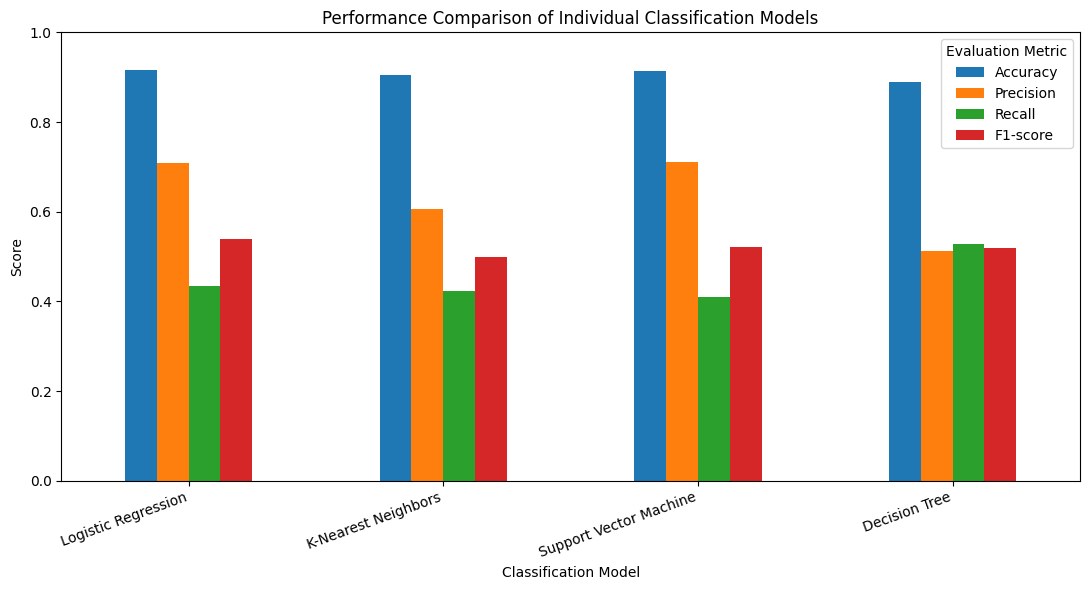

In [94]:
comparison_plot = (
    individual_model_results
    .set_index("Model")
)

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Performance Comparison of Individual Classification Models"
)

plt.ylabel("Score")
plt.xlabel("Classification Model")

plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Evaluation Metric"
)

plt.tight_layout()
plt.show()

In [95]:
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import matplotlib.pyplot as plt

print("Ensemble learning libraries imported successfully.")

Ensemble learning libraries imported successfully.


In [96]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [97]:
y_pred_rf = random_forest_model.predict(
    X_test_processed
)
rf_accuracy = accuracy_score(
    y_test, y_pred_rf
)

rf_precision = precision_score(
    y_test, y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test, y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test, y_pred_rf,
    zero_division=0
)

print("RANDOM FOREST PERFORMANCE")
print("-" * 45)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-score  : {rf_f1:.4f}")

RANDOM FOREST PERFORMANCE
---------------------------------------------
Accuracy  : 0.9184
Precision : 0.6969
Recall    : 0.4881
F1-score  : 0.5741


In [98]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Not Subscribed",
            "Subscribed"
        ],
        zero_division=0
    )
)

Random Forest Classification Report:

                precision    recall  f1-score   support

Not Subscribed       0.94      0.97      0.95      7310
    Subscribed       0.70      0.49      0.57       928

      accuracy                           0.92      8238
     macro avg       0.82      0.73      0.76      8238
  weighted avg       0.91      0.92      0.91      8238



In [99]:
rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[7113  197]
 [ 475  453]]


In [100]:
bagging_model = BaggingClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(
    X_train_processed,
    y_train
)

print("Bagging Classifier trained successfully.")

Bagging Classifier trained successfully.


In [101]:
y_pred_bagging = bagging_model.predict(
    X_test_processed
)
bagging_accuracy = accuracy_score(
    y_test, y_pred_bagging
)

bagging_precision = precision_score(
    y_test, y_pred_bagging,
    zero_division=0
)

bagging_recall = recall_score(
    y_test, y_pred_bagging,
    zero_division=0
)

bagging_f1 = f1_score(
    y_test, y_pred_bagging,
    zero_division=0
)

print("BAGGING CLASSIFIER PERFORMANCE")
print("-" * 45)

print(f"Accuracy  : {bagging_accuracy:.4f}")
print(f"Precision : {bagging_precision:.4f}")
print(f"Recall    : {bagging_recall:.4f}")
print(f"F1-score  : {bagging_f1:.4f}")

BAGGING CLASSIFIER PERFORMANCE
---------------------------------------------
Accuracy  : 0.9185
Precision : 0.6633
Recall    : 0.5625
F1-score  : 0.6087


In [102]:
print("Bagging Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_bagging,
        target_names=[
            "Not Subscribed",
            "Subscribed"
        ],
        zero_division=0
    )
)

Bagging Classification Report:

                precision    recall  f1-score   support

Not Subscribed       0.95      0.96      0.95      7310
    Subscribed       0.66      0.56      0.61       928

      accuracy                           0.92      8238
     macro avg       0.80      0.76      0.78      8238
  weighted avg       0.91      0.92      0.92      8238



In [103]:
bagging_cm = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("Bagging Confusion Matrix:")
print(bagging_cm)

Bagging Confusion Matrix:
[[7045  265]
 [ 406  522]]


In [104]:
adaboost_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

adaboost_model.fit(
    X_train_processed,
    y_train
)

print("AdaBoost model trained successfully.")

AdaBoost model trained successfully.


In [105]:
y_pred_adaboost = adaboost_model.predict(
    X_test_processed
)
ada_accuracy = accuracy_score(
    y_test, y_pred_adaboost
)

ada_precision = precision_score(
    y_test, y_pred_adaboost,
    zero_division=0
)

ada_recall = recall_score(
    y_test, y_pred_adaboost,
    zero_division=0
)

ada_f1 = f1_score(
    y_test, y_pred_adaboost,
    zero_division=0
)

print("ADABOOST PERFORMANCE")
print("-" * 45)

print(f"Accuracy  : {ada_accuracy:.4f}")
print(f"Precision : {ada_precision:.4f}")
print(f"Recall    : {ada_recall:.4f}")
print(f"F1-score  : {ada_f1:.4f}")

ADABOOST PERFORMANCE
---------------------------------------------
Accuracy  : 0.9059
Precision : 0.6937
Recall    : 0.2953
F1-score  : 0.4142


In [106]:
print("AdaBoost Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_adaboost,
        target_names=[
            "Not Subscribed",
            "Subscribed"
        ],
        zero_division=0
    )
)

AdaBoost Classification Report:

                precision    recall  f1-score   support

Not Subscribed       0.92      0.98      0.95      7310
    Subscribed       0.69      0.30      0.41       928

      accuracy                           0.91      8238
     macro avg       0.81      0.64      0.68      8238
  weighted avg       0.89      0.91      0.89      8238



In [107]:
ada_cm = confusion_matrix(
    y_test,
    y_pred_adaboost
)

print("AdaBoost Confusion Matrix:")
print(ada_cm)

AdaBoost Confusion Matrix:
[[7189  121]
 [ 654  274]]


In [108]:
print(type(X_train_processed))

<class 'numpy.ndarray'>


In [109]:
if hasattr(X_train_processed, "toarray"):
    X_train_gb = X_train_processed.toarray()
    X_test_gb = X_test_processed.toarray()
else:
    X_train_gb = X_train_processed
    X_test_gb = X_test_processed

print("Gradient Boosting training shape:", X_train_gb.shape)
print("Gradient Boosting testing shape :", X_test_gb.shape)

Gradient Boosting training shape: (32950, 53)
Gradient Boosting testing shape : (8238, 53)


In [110]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train_gb,
    y_train
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [111]:
y_pred_gb = gradient_boosting_model.predict(
    X_test_gb
)

In [112]:
gb_accuracy = accuracy_score(
    y_test, y_pred_gb
)

gb_precision = precision_score(
    y_test, y_pred_gb,
    zero_division=0
)

gb_recall = recall_score(
    y_test, y_pred_gb,
    zero_division=0
)

gb_f1 = f1_score(
    y_test, y_pred_gb,
    zero_division=0
)

print("GRADIENT BOOSTING PERFORMANCE")
print("-" * 45)

print(f"Accuracy  : {gb_accuracy:.4f}")
print(f"Precision : {gb_precision:.4f}")
print(f"Recall    : {gb_recall:.4f}")
print(f"F1-score  : {gb_f1:.4f}")

GRADIENT BOOSTING PERFORMANCE
---------------------------------------------
Accuracy  : 0.9216
Precision : 0.6926
Recall    : 0.5463
F1-score  : 0.6108


In [113]:
print("Gradient Boosting Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=[
            "Not Subscribed",
            "Subscribed"
        ],
        zero_division=0
    )
)

Gradient Boosting Classification Report:

                precision    recall  f1-score   support

Not Subscribed       0.94      0.97      0.96      7310
    Subscribed       0.69      0.55      0.61       928

      accuracy                           0.92      8238
     macro avg       0.82      0.76      0.78      8238
  weighted avg       0.92      0.92      0.92      8238



In [114]:
gb_cm = confusion_matrix(
    y_test,
    y_pred_gb
)

print("Gradient Boosting Confusion Matrix:")
print(gb_cm)

Gradient Boosting Confusion Matrix:
[[7085  225]
 [ 421  507]]


In [115]:
ensemble_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Bagging Classifier",
        "AdaBoost",
        "Gradient Boosting"
    ],

    "Accuracy": [
        rf_accuracy,
        bagging_accuracy,
        ada_accuracy,
        gb_accuracy
    ],

    "Precision": [
        rf_precision,
        bagging_precision,
        ada_precision,
        gb_precision
    ],

    "Recall": [
        rf_recall,
        bagging_recall,
        ada_recall,
        gb_recall
    ],

    "F1-score": [
        rf_f1,
        bagging_f1,
        ada_f1,
        gb_f1
    ]
})

display(
    ensemble_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.9184,0.6969,0.4881,0.5741
1,Bagging Classifier,0.9185,0.6633,0.5625,0.6087
2,AdaBoost,0.9059,0.6937,0.2953,0.4142
3,Gradient Boosting,0.9216,0.6926,0.5463,0.6108


In [116]:
ensemble_results.sort_values(
    by="F1-score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score
3,Gradient Boosting,0.921583,0.692623,0.546336,0.610843
1,Bagging Classifier,0.918548,0.663278,0.562500,0.608746
0,Random Forest,0.918427,0.696923,0.488147,0.574144
2,AdaBoost,0.905924,0.693671,0.295259,0.414210


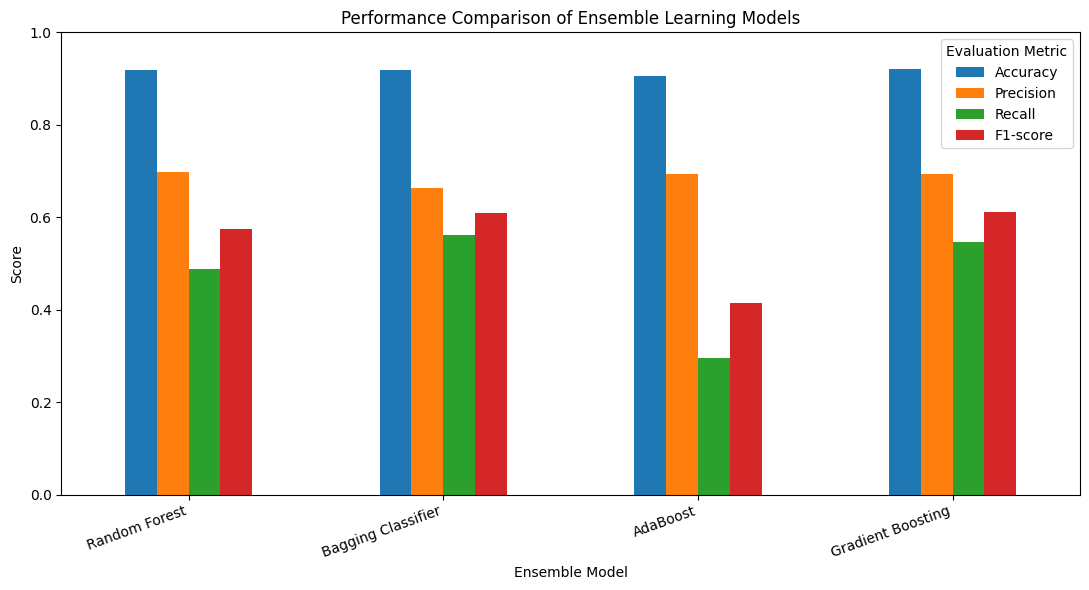

In [117]:
ensemble_plot = ensemble_results.set_index(
    "Model"
)

ensemble_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Performance Comparison of Ensemble Learning Models"
)

plt.xlabel("Ensemble Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Evaluation Metric"
)

plt.tight_layout()
plt.show()

In [118]:
all_model_results = pd.concat(
    [
        individual_model_results,
        ensemble_results
    ],
    ignore_index=True
)

display(
    all_model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9162,0.7095,0.4343,0.5388
1,K-Nearest Neighbors,0.9041,0.6068,0.4224,0.4981
2,Support Vector Machine,0.9148,0.7108,0.4106,0.5205
3,Decision Tree,0.8900,0.5115,0.5280,0.5196
4,Random Forest,0.9184,0.6969,0.4881,0.5741
5,Bagging Classifier,0.9185,0.6633,0.5625,0.6087
6,AdaBoost,0.9059,0.6937,0.2953,0.4142
7,Gradient Boosting,0.9216,0.6926,0.5463,0.6108


In [119]:
all_model_results.sort_values(
    by="F1-score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score
7,Gradient Boosting,0.921583,0.692623,0.546336,0.610843
5,Bagging Classifier,0.918548,0.663278,0.562500,0.608746
4,Random Forest,0.918427,0.696923,0.488147,0.574144
0,Logistic Regression,0.916242,0.709507,0.434267,0.538770
2,Support Vector Machine,0.914785,0.710821,0.410560,0.520492
3,Decision Tree,0.890022,0.511482,0.528017,0.519618
1,K-Nearest Neighbors,0.904103,0.606811,0.422414,0.498094
6,AdaBoost,0.905924,0.693671,0.295259,0.414210


In [120]:
best_model_row = (
    all_model_results
    .sort_values(
        by="F1-score",
        ascending=False
    )
    .iloc[0]
)

print("BEST PERFORMING MODEL")
print("-" * 40)

print("Model     :", best_model_row["Model"])
print(f"Accuracy  : {best_model_row['Accuracy']:.4f}")
print(f"Precision : {best_model_row['Precision']:.4f}")
print(f"Recall    : {best_model_row['Recall']:.4f}")
print(f"F1-score  : {best_model_row['F1-score']:.4f}")

BEST PERFORMING MODEL
----------------------------------------
Model     : Gradient Boosting
Accuracy  : 0.9216
Precision : 0.6926
Recall    : 0.5463
F1-score  : 0.6108


In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Evaluation libraries imported successfully.")

Evaluation libraries imported successfully.


In [122]:
def evaluate_model(model_name, y_true, y_pred, model_type):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return {
        "Model": model_name,
        "Type": model_type,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

print("Evaluation function created successfully.")

Evaluation function created successfully.


In [124]:
individual_results = [

    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_logistic,
        "Individual"
    ),

    evaluate_model(
        "K-Nearest Neighbors",
        y_test,
        y_pred_knn,
        "Individual"
    ),

    evaluate_model(
        "Support Vector Machine",
        y_test,
        y_pred_svm,
        "Individual"
    ),

    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_tree,
        "Individual"
    )
]

individual_results_df = pd.DataFrame(
    individual_results
)

individual_results_df

,Model,Type,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Individual,0.916242,0.709507,0.434267,0.538770
1,K-Nearest Neighbors,Individual,0.904103,0.606811,0.422414,0.498094
2,Support Vector Machine,Individual,0.914785,0.710821,0.410560,0.520492
3,Decision Tree,Individual,0.890022,0.511482,0.528017,0.519618


In [125]:
display(
    individual_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Type,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Individual,0.9162,0.7095,0.4343,0.5388
1,K-Nearest Neighbors,Individual,0.9041,0.6068,0.4224,0.4981
2,Support Vector Machine,Individual,0.9148,0.7108,0.4106,0.5205
3,Decision Tree,Individual,0.8900,0.5115,0.5280,0.5196


In [126]:
ensemble_results = [

    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        "Ensemble"
    ),

    evaluate_model(
        "Bagging Classifier",
        y_test,
        y_pred_bagging,
        "Ensemble"
    ),

    evaluate_model(
        "AdaBoost",
        y_test,
        y_pred_adaboost,
        "Ensemble"
    ),

    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb,
        "Ensemble"
    )
]

ensemble_results_df = pd.DataFrame(
    ensemble_results
)

display(
    ensemble_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Type,Accuracy,Precision,Recall,F1-score
0,Random Forest,Ensemble,0.9184,0.6969,0.4881,0.5741
1,Bagging Classifier,Ensemble,0.9185,0.6633,0.5625,0.6087
2,AdaBoost,Ensemble,0.9059,0.6937,0.2953,0.4142
3,Gradient Boosting,Ensemble,0.9216,0.6926,0.5463,0.6108


In [128]:
all_results = pd.concat(
    [
        individual_results_df,
        ensemble_results_df
    ],
    ignore_index=True
)

display(
    all_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Type,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Individual,0.9162,0.7095,0.4343,0.5388
1,K-Nearest Neighbors,Individual,0.9041,0.6068,0.4224,0.4981
2,Support Vector Machine,Individual,0.9148,0.7108,0.4106,0.5205
3,Decision Tree,Individual,0.8900,0.5115,0.5280,0.5196
4,Random Forest,Ensemble,0.9184,0.6969,0.4881,0.5741
5,Bagging Classifier,Ensemble,0.9185,0.6633,0.5625,0.6087
6,AdaBoost,Ensemble,0.9059,0.6937,0.2953,0.4142
7,Gradient Boosting,Ensemble,0.9216,0.6926,0.5463,0.6108


In [129]:
ranked_results = (
    all_results
    .sort_values(
        by="F1-score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_results.index = (
    ranked_results.index + 1
)

display(
    ranked_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Type,Accuracy,Precision,Recall,F1-score
1,Gradient Boosting,Ensemble,0.9216,0.6926,0.5463,0.6108
2,Bagging Classifier,Ensemble,0.9185,0.6633,0.5625,0.6087
3,Random Forest,Ensemble,0.9184,0.6969,0.4881,0.5741
4,Logistic Regression,Individual,0.9162,0.7095,0.4343,0.5388
5,Support Vector Machine,Individual,0.9148,0.7108,0.4106,0.5205
6,Decision Tree,Individual,0.8900,0.5115,0.5280,0.5196
7,K-Nearest Neighbors,Individual,0.9041,0.6068,0.4224,0.4981
8,AdaBoost,Ensemble,0.9059,0.6937,0.2953,0.4142


In [130]:
best_model = ranked_results.iloc[0]

print("=" * 50)
print("BEST PERFORMING MODEL")
print("=" * 50)

print("Model     :", best_model["Model"])
print("Type      :", best_model["Type"])

print(
    f"Accuracy  : {best_model['Accuracy']:.4f}"
)

print(
    f"Precision : {best_model['Precision']:.4f}"
)

print(
    f"Recall    : {best_model['Recall']:.4f}"
)

print(
    f"F1-score  : {best_model['F1-score']:.4f}"
)

BEST PERFORMING MODEL
Model     : Gradient Boosting
Type      : Ensemble
Accuracy  : 0.9216
Precision : 0.6926
Recall    : 0.5463
F1-score  : 0.6108


In [131]:
type_comparison = (
    all_results
    .groupby("Type")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score"
        ]
    ]
    .mean()
)

display(
    type_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Accuracy,Precision,Recall,F1-score
Type,,,,
Ensemble,0.9161,0.6866,0.4731,0.5520
Individual,0.9063,0.6347,0.4488,0.5192


In [132]:
best_individual = (
    individual_results_df
    .sort_values(
        "F1-score",
        ascending=False
    )
    .iloc[0]
)

print("BEST INDIVIDUAL MODEL")
print("-" * 40)

print("Model:", best_individual["Model"])

print(
    f"Accuracy  : {best_individual['Accuracy']:.4f}"
)

print(
    f"Precision : {best_individual['Precision']:.4f}"
)

print(
    f"Recall    : {best_individual['Recall']:.4f}"
)

print(
    f"F1-score  : {best_individual['F1-score']:.4f}"
)

BEST INDIVIDUAL MODEL
----------------------------------------
Model: Logistic Regression
Accuracy  : 0.9162
Precision : 0.7095
Recall    : 0.4343
F1-score  : 0.5388


In [133]:
best_ensemble = (
    ensemble_results_df
    .sort_values(
        "F1-score",
        ascending=False
    )
    .iloc[0]
)

print("BEST ENSEMBLE MODEL")
print("-" * 40)

print("Model:", best_ensemble["Model"])

print(
    f"Accuracy  : {best_ensemble['Accuracy']:.4f}"
)

print(
    f"Precision : {best_ensemble['Precision']:.4f}"
)

print(
    f"Recall    : {best_ensemble['Recall']:.4f}"
)

print(
    f"F1-score  : {best_ensemble['F1-score']:.4f}"
)

BEST ENSEMBLE MODEL
----------------------------------------
Model: Gradient Boosting
Accuracy  : 0.9216
Precision : 0.6926
Recall    : 0.5463
F1-score  : 0.6108


In [134]:
best_comparison = pd.DataFrame([
    best_individual,
    best_ensemble
])

display(
    best_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Type,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Individual,0.9162,0.7095,0.4343,0.5388
3,Gradient Boosting,Ensemble,0.9216,0.6926,0.5463,0.6108


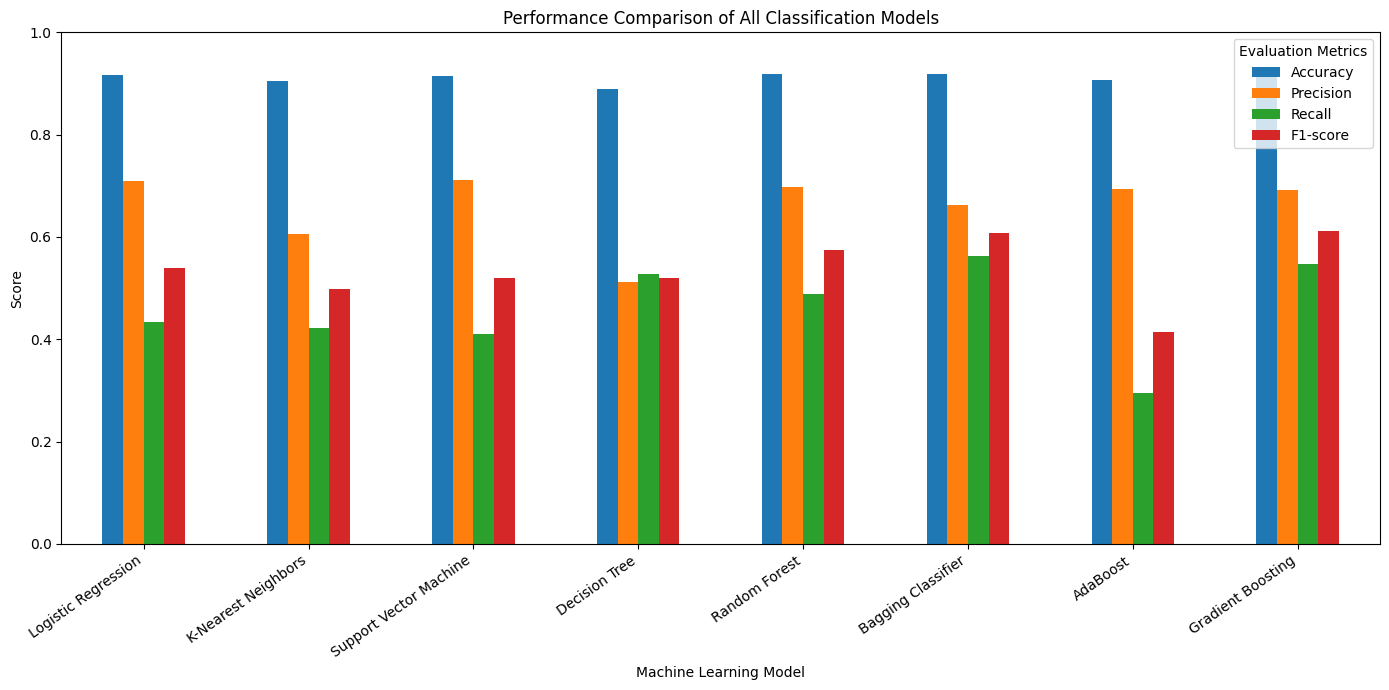

In [135]:
plot_data = (
    all_results
    .set_index("Model")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score"
        ]
    ]
)

plot_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Performance Comparison of All Classification Models"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    title="Evaluation Metrics"
)

plt.tight_layout()
plt.show()

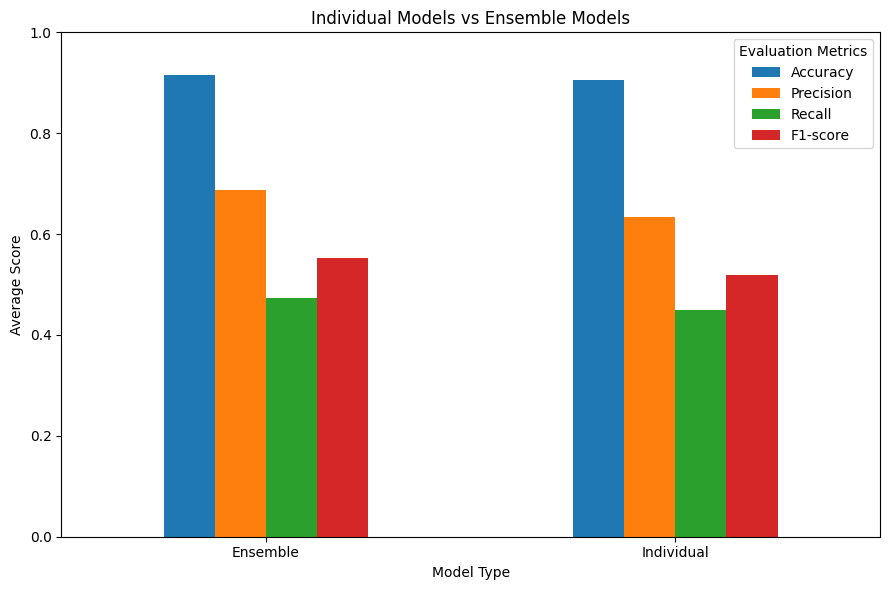

In [136]:
type_comparison.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title(
    "Individual Models vs Ensemble Models"
)

plt.xlabel("Model Type")
plt.ylabel("Average Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Evaluation Metrics"
)

plt.tight_layout()
plt.show()

In [137]:
prediction_dictionary = {
    "Logistic Regression": y_pred_logistic,
    "K-Nearest Neighbors": y_pred_knn,
    "Support Vector Machine": y_pred_svm,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Bagging Classifier": y_pred_bagging,
    "AdaBoost": y_pred_adaboost,
    "Gradient Boosting": y_pred_gb
}

for model_name, predictions in prediction_dictionary.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    print("\n", "=" * 50)
    print(model_name)
    print("=" * 50)

    print(cm)


Logistic Regression
[[7145  165]
 [ 525  403]]

K-Nearest Neighbors
[[7056  254]
 [ 536  392]]

Support Vector Machine
[[7155  155]
 [ 547  381]]

Decision Tree
[[6842  468]
 [ 438  490]]

Random Forest
[[7113  197]
 [ 475  453]]

Bagging Classifier
[[7045  265]
 [ 406  522]]

AdaBoost
[[7189  121]
 [ 654  274]]

Gradient Boosting
[[7085  225]
 [ 421  507]]


In [138]:
individual_avg_f1 = (
    individual_results_df["F1-score"].mean()
)

ensemble_avg_f1 = (
    ensemble_results_df["F1-score"].mean()
)

print(
    f"Average Individual Model F1-score: "
    f"{individual_avg_f1:.4f}"
)

print(
    f"Average Ensemble Model F1-score: "
    f"{ensemble_avg_f1:.4f}"
)

if ensemble_avg_f1 > individual_avg_f1:

    print(
        "\nOverall, ensemble models achieved "
        "a higher average F1-score."
    )

elif individual_avg_f1 > ensemble_avg_f1:

    print(
        "\nOverall, individual models achieved "
        "a higher average F1-score."
    )

else:

    print(
        "\nIndividual and ensemble models achieved "
        "the same average F1-score."
    )

Average Individual Model F1-score: 0.5192
Average Ensemble Model F1-score: 0.5520

Overall, ensemble models achieved a higher average F1-score.


In [139]:
# Rank all models primarily by F1-score

model_ranking = all_results.sort_values(
    by=["F1-score", "Recall", "Precision", "Accuracy"],
    ascending=False
).reset_index(drop=True)

model_ranking.index = model_ranking.index + 1

display(
    model_ranking.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

,Model,Type,Accuracy,Precision,Recall,F1-score
1,Gradient Boosting,Ensemble,0.9216,0.6926,0.5463,0.6108
2,Bagging Classifier,Ensemble,0.9185,0.6633,0.5625,0.6087
3,Random Forest,Ensemble,0.9184,0.6969,0.4881,0.5741
4,Logistic Regression,Individual,0.9162,0.7095,0.4343,0.5388
5,Support Vector Machine,Individual,0.9148,0.7108,0.4106,0.5205
6,Decision Tree,Individual,0.8900,0.5115,0.5280,0.5196
7,K-Nearest Neighbors,Individual,0.9041,0.6068,0.4224,0.4981
8,AdaBoost,Ensemble,0.9059,0.6937,0.2953,0.4142


In [140]:
best_model_result = model_ranking.iloc[0]

print("=" * 55)
print("BEST-PERFORMING MODEL")
print("=" * 55)

print("Model     :", best_model_result["Model"])
print("Type      :", best_model_result["Type"])

print(
    f"Accuracy  : {best_model_result['Accuracy']:.4f}"
)

print(
    f"Precision : {best_model_result['Precision']:.4f}"
)

print(
    f"Recall    : {best_model_result['Recall']:.4f}"
)

print(
    f"F1-score  : {best_model_result['F1-score']:.4f}"
)

BEST-PERFORMING MODEL
Model     : Gradient Boosting
Type      : Ensemble
Accuracy  : 0.9216
Precision : 0.6926
Recall    : 0.5463
F1-score  : 0.6108


In [141]:
best_model_name = best_model_result["Model"]

print(
    f"The best-performing model is {best_model_name}."
)

print(
    f"It achieved an accuracy of "
    f"{best_model_result['Accuracy']:.4f}, "
    f"precision of {best_model_result['Precision']:.4f}, "
    f"recall of {best_model_result['Recall']:.4f}, "
    f"and F1-score of {best_model_result['F1-score']:.4f}."
)

print(
    "\nThe model was selected primarily based on its F1-score, "
    "while also considering recall, precision, and accuracy."
)

print(
    "F1-score is particularly useful because the target classes "
    "are imbalanced and it balances precision and recall."
)

The best-performing model is Gradient Boosting.
It achieved an accuracy of 0.9216, precision of 0.6926, recall of 0.5463, and F1-score of 0.6108.

The model was selected primarily based on its F1-score, while also considering recall, precision, and accuracy.
F1-score is particularly useful because the target classes are imbalanced and it balances precision and recall.


In [142]:
trained_models = {
    "Logistic Regression": logistic_model,
    "K-Nearest Neighbors": knn_model,
    "Support Vector Machine": svm_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Bagging Classifier": bagging_model,
    "AdaBoost": adaboost_model,
    "Gradient Boosting": gradient_boosting_model
}

best_trained_model = trained_models[
    best_model_name
]

print(
    "Selected trained model:",
    best_model_name
)

Selected trained model: Gradient Boosting


In [145]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

In [146]:
if best_model_name == "Gradient Boosting":
    X_importance = X_test_gb
else:
    X_importance = X_test_processed

In [147]:
permutation_result = permutation_importance(
    best_trained_model,
    X_importance,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": permutation_result.importances_mean
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,duration,0.318415
1,nr.employed,0.131283
2,emp.var.rate,0.032164
3,pdays,0.023933
4,cons.conf.idx,0.014053
5,contact_telephone,0.012430
6,month_mar,0.009703
7,month_oct,0.005900
8,education_university.degree,0.005195
9,poutcome_success,0.004249


In [148]:
top_features = feature_importance.head(10)

display(
    top_features.style.format({
        "Importance": "{:.4f}"
    })
)

,Feature,Importance
0,duration,0.3184
1,nr.employed,0.1313
2,emp.var.rate,0.0322
3,pdays,0.0239
4,cons.conf.idx,0.0141
5,contact_telephone,0.0124
6,month_mar,0.0097
7,month_oct,0.0059
8,education_university.degree,0.0052
9,poutcome_success,0.0042


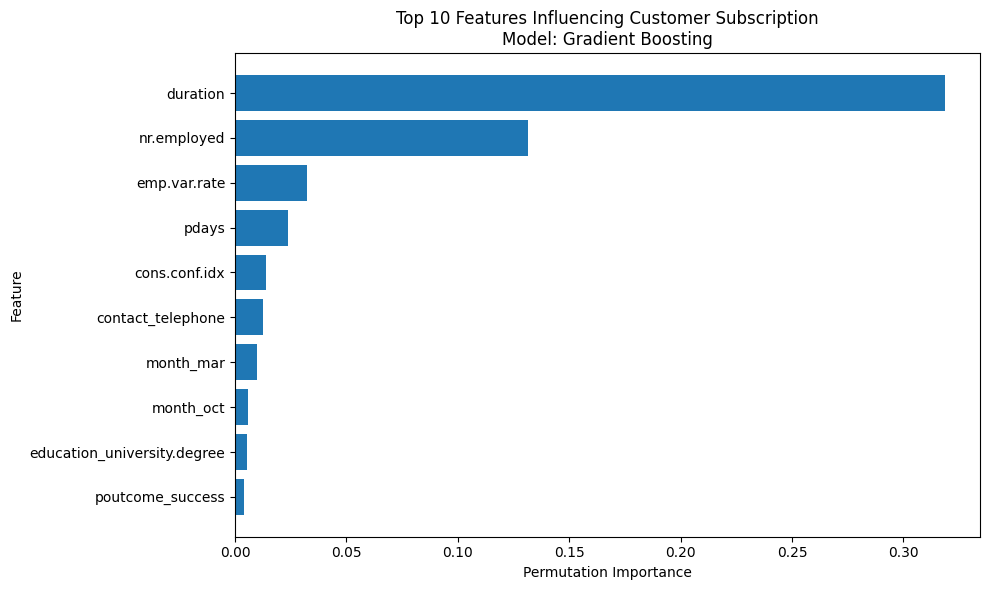

In [149]:
top_features_plot = (
    top_features
    .sort_values("Importance")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features_plot["Feature"],
    top_features_plot["Importance"]
)

plt.title(
    f"Top 10 Features Influencing Customer Subscription\n"
    f"Model: {best_model_name}"
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [150]:
feature_importance[
    feature_importance["Feature"].str.contains(
        "duration",
        case=False
    )
]

,Feature,Importance
0,duration,0.318415


In [151]:
print("TOP FIVE INFLUENTIAL FEATURES")
print("=" * 50)

for i, row in top_features.head(5).iterrows():

    print(
        f"{i + 1}. {row['Feature']} "
        f"- Importance: {row['Importance']:.4f}"
    )

TOP FIVE INFLUENTIAL FEATURES
1. duration - Importance: 0.3184
2. nr.employed - Importance: 0.1313
3. emp.var.rate - Importance: 0.0322
4. pdays - Importance: 0.0239
5. cons.conf.idx - Importance: 0.0141


In [153]:
if hasattr(best_trained_model, "predict_proba"):

    if best_model_name == "Gradient Boosting":
        probability_data = X_test_gb
    else:
        probability_data = X_test_processed

    subscription_probability = (
        best_trained_model.predict_proba(
            probability_data
        )[:, 1]
    )

    customer_predictions = pd.DataFrame({
        "Actual": y_test.values,
        "Subscription Probability":
            subscription_probability
    })

    customer_predictions = (
        customer_predictions
        .sort_values(
            "Subscription Probability",
            ascending=False
        )
    )

    display(
        customer_predictions.head(20)
    )

,Actual,Subscription Probability
7333,1,0.908776
1053,0,0.906718
2421,1,0.906628
4792,1,0.905471
21,1,0.905114
7316,0,0.904308
3418,1,0.901877
4500,1,0.901381
6657,1,0.899402
6743,1,0.899146


In [154]:
print("=" * 60)
print("FINAL MODEL SELECTION SUMMARY")
print("=" * 60)

print(
    "\nBest Model:",
    best_model_name
)

print(
    f"Accuracy : "
    f"{best_model_result['Accuracy']:.4f}"
)

print(
    f"Precision: "
    f"{best_model_result['Precision']:.4f}"
)

print(
    f"Recall   : "
    f"{best_model_result['Recall']:.4f}"
)

print(
    f"F1-score : "
    f"{best_model_result['F1-score']:.4f}"
)

print("\nTop 10 Influential Features:")

display(
    feature_importance.head(10)
)

FINAL MODEL SELECTION SUMMARY

Best Model: Gradient Boosting
Accuracy : 0.9216
Precision: 0.6926
Recall   : 0.5463
F1-score : 0.6108

Top 10 Influential Features:


,Feature,Importance
0,duration,0.318415
1,nr.employed,0.131283
2,emp.var.rate,0.032164
3,pdays,0.023933
4,cons.conf.idx,0.014053
5,contact_telephone,0.012430
6,month_mar,0.009703
7,month_oct,0.005900
8,education_university.degree,0.005195
9,poutcome_success,0.004249


In [155]:
from sklearn.model_selection import cross_val_score

# Select correct processed dataset
if best_model_name == "Gradient Boosting":
    X_cv = X_train_gb
else:
    X_cv = X_train_processed

# 5-fold cross-validation using F1-score
cv_f1_scores = cross_val_score(
    best_trained_model,
    X_cv,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Best Model:", best_model_name)

print("\nF1-scores for each fold:")
print(cv_f1_scores)

print(
    f"\nMean F1-score: {cv_f1_scores.mean():.4f}"
)

print(
    f"Standard Deviation: {cv_f1_scores.std():.4f}"
)

Best Model: Gradient Boosting

F1-scores for each fold:
[0.59419211 0.60015004 0.55471125 0.57582418 0.59618209]

Mean F1-score: 0.5842
Standard Deviation: 0.0170


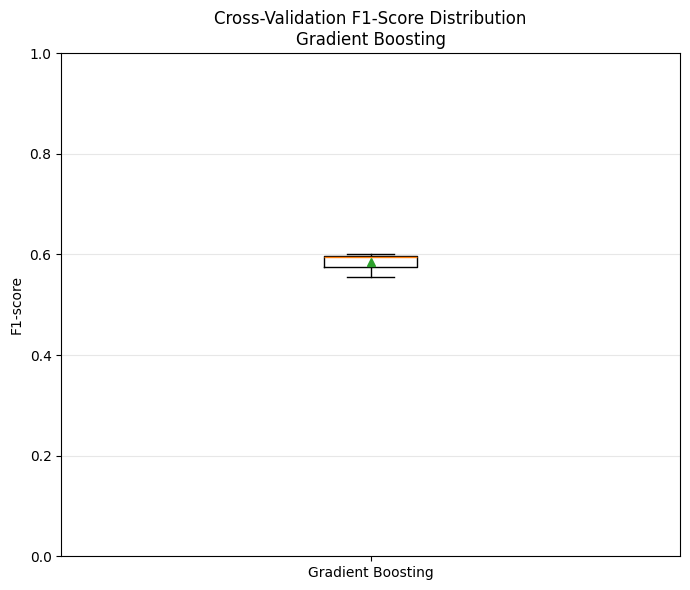

In [156]:
plt.figure(figsize=(7, 6))

plt.boxplot(
    cv_f1_scores,
    tick_labels=[best_model_name],
    showmeans=True
)

plt.title(
    f"Cross-Validation F1-Score Distribution\n{best_model_name}"
)

plt.ylabel("F1-score")
plt.ylim(0, 1)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [157]:
metrics = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-score": "f1"
}

cv_metric_scores = {}

for metric_name, scoring_method in metrics.items():

    scores = cross_val_score(
        best_trained_model,
        X_cv,
        y_train,
        cv=5,
        scoring=scoring_method,
        n_jobs=-1
    )

    cv_metric_scores[metric_name] = scores

cv_scores_df = pd.DataFrame(
    cv_metric_scores
)

display(
    cv_scores_df.style.format("{:.4f}")
)

,Accuracy,Precision,Recall,F1-score
0,0.9173,0.6639,0.5377,0.5942
1,0.9191,0.6768,0.5391,0.6002
2,0.9111,0.6359,0.4919,0.5547
3,0.9121,0.6318,0.5289,0.5758
4,0.9165,0.6559,0.5464,0.5962


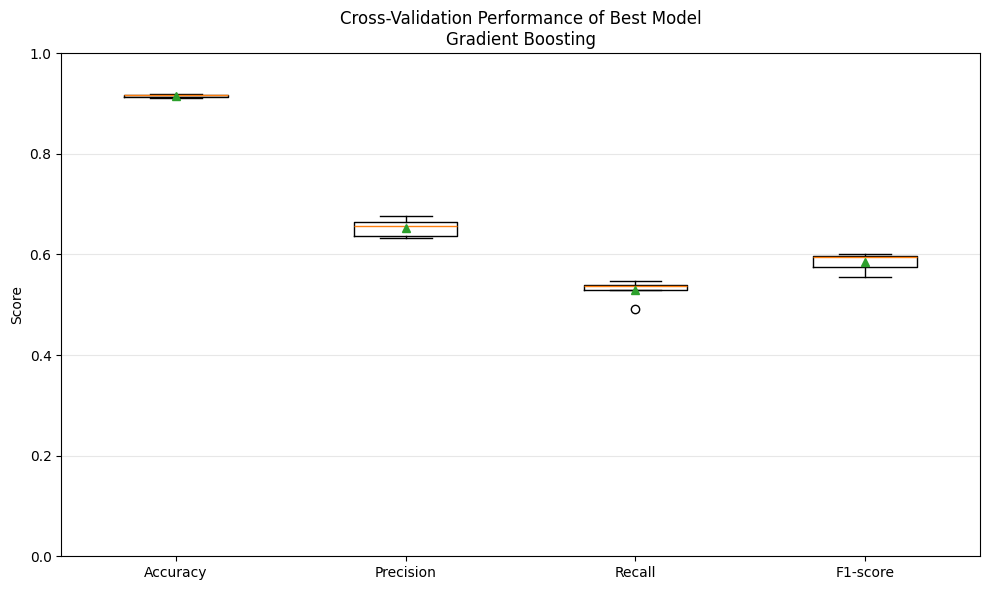

In [158]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        cv_scores_df["Accuracy"],
        cv_scores_df["Precision"],
        cv_scores_df["Recall"],
        cv_scores_df["F1-score"]
    ],
    tick_labels=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    showmeans=True
)

plt.title(
    f"Cross-Validation Performance of Best Model\n"
    f"{best_model_name}"
)

plt.ylabel("Score")
plt.ylim(0, 1)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()